# Posture Detection V2 — 07 MultiPosture Public-Data Classifier

Downloads and audits the Zenodo MultiPosture skeleton dataset, trains an upper-body posture classifier with participant-independent splits, evaluates macro-F1, and saves a model contract for later webcam integration. Raw videos are not included in this dataset, so this improves the classification layer—not MotionBERT depth lifting.

## 1. Setup and download

In [1]:
# Uncomment if needed: %pip install -q scikit-learn joblib seaborn
import hashlib, json, re, urllib.request
from datetime import datetime, timezone
from pathlib import Path
import joblib, matplotlib.pyplot as plt, numpy as np, pandas as pd, seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit

wd=Path.cwd(); ROOT=wd.parent if wd.name=='notebooks' else wd if wd.name=='project_v2' else wd/'project_v2'
DATA_DIR=ROOT/'data'/'public_multiposture'; RESULT_DIR=ROOT/'results'/'multiposture'; MODEL_DIR=ROOT/'models'
for d in (DATA_DIR,RESULT_DIR,MODEL_DIR): d.mkdir(parents=True,exist_ok=True)
DOI='10.5281/zenodo.14230872'; URL='https://zenodo.org/records/14230872/files/data.csv?download=1'; CSV=DATA_DIR/'data.csv'
if not CSV.exists(): urllib.request.urlretrieve(URL,CSV)
digest=hashlib.md5(CSV.read_bytes()).hexdigest(); print('File:',CSV.resolve()); print('MB:',round(CSV.stat().st_size/1e6,2),'MD5:',digest)
if digest!='7efbc94d653acf32eefecec3ff26d6c6': print('WARNING: checksum differs from the published Zenodo record.')

File: C:\Users\manth\Desktop\project_v2\data\public_multiposture\data.csv
MB: 9.33 MD5: 7efbc94d653acf32eefecec3ff26d6c6


## 2. Schema audit

In [2]:
data=pd.read_csv(CSV); data.columns=[str(c).strip() for c in data.columns]
print('Shape:',data.shape); display(pd.DataFrame({'column':data.columns,'dtype':data.dtypes.astype(str),'missing':data.isna().sum().values,'unique':[data[c].nunique(dropna=True) for c in data.columns]}))
display(data.head()); print('Duplicate rows:',int(data.duplicated().sum()))
def choose(patterns,columns):
    for p in patterns:
        hits=[c for c in columns if re.search(p,c,re.I)]
        if hits:return hits[0]
    return None
UPPER_LABEL=choose([r'upper.*(label|posture|class)',r'(label|posture|class).*upper',r'^upper$',r'^label_?1$'],data.columns)
PARTICIPANT=choose([r'participant',r'subject',r'person',r'user'],data.columns)
print('Detected upper label:',UPPER_LABEL); print('Detected participant column:',PARTICIPANT)
if UPPER_LABEL is None: raise ValueError('Upper-body label column was not detected. Inspect the table and set UPPER_LABEL manually.')
if PARTICIPANT is None: raise ValueError('Participant identifier was not detected. Do not use a random frame split; set PARTICIPANT manually after inspecting the schema.')

Shape: (4794, 102)


,column,dtype,missing,unique
subject,subject,int64,0,13
upperbody_label,upperbody_label,str,0,5
lowerbody_label,lowerbody_label,str,0,7
nose_x,nose_x,float64,0,4794
nose_y,nose_y,float64,0,4788
...,...,...,...,...
left_foot_index_y,left_foot_index_y,float64,0,4793
left_foot_index_z,left_foot_index_z,float64,0,4793
right_foot_index_x,right_foot_index_x,float64,0,4793
right_foot_index_y,right_foot_index_y,float64,0,4791


,subject,upperbody_label,lowerbody_label,nose_x,nose_y,nose_z,left_eye_inner_x,left_eye_inner_y,left_eye_inner_z,left_eye_x,...,left_heel_z,right_heel_x,right_heel_y,right_heel_z,left_foot_index_x,left_foot_index_y,left_foot_index_z,right_foot_index_x,right_foot_index_y,right_foot_index_z
0,1,TLB,LCL,0.013146,-0.534424,-0.176213,0.019678,-0.557297,-0.160404,0.021779,...,-0.313284,-0.074499,0.623198,-0.041134,-0.362046,0.284611,-0.416112,-0.083041,0.690973,-0.153205
1,1,TLB,LCL,-0.027462,-0.499347,-0.235089,-0.013835,-0.522232,-0.217069,-0.012026,...,-0.339221,0.018673,0.683186,-0.037659,-0.247262,0.340290,-0.444570,0.034586,0.751673,-0.148952
2,1,TLB,LCL,-0.017639,-0.542063,-0.223344,-0.000430,-0.562522,-0.202060,0.001764,...,-0.243208,0.049054,0.677385,-0.036760,-0.249142,0.455043,-0.314104,0.051902,0.745649,-0.125802
3,1,TLB,LCL,-0.027630,-0.556502,-0.149826,-0.007174,-0.575659,-0.129025,-0.005589,...,-0.306242,0.065110,0.672955,0.004685,-0.261612,0.440069,-0.395166,0.057489,0.747611,-0.082085
4,1,TLB,LCL,-0.033802,-0.556527,-0.174968,-0.012644,-0.575930,-0.154702,-0.011082,...,-0.310197,0.063744,0.668368,0.012122,-0.265350,0.453247,-0.398636,0.061104,0.747678,-0.075673


Duplicate rows: 0
Detected upper label: upperbody_label
Detected participant column: subject


## 3. Feature and label contract

In [3]:
LABEL_MAP={'TUP':'upright','TLB':'lean_backward','TLF':'lean_forward','TLR':'lean_right','TLL':'lean_left'}
labels=data[UPPER_LABEL].astype(str).str.strip().str.upper().map(LABEL_MAP)
excluded={UPPER_LABEL,PARTICIPANT}; excluded.update(c for c in data.columns if re.search(r'label|class|posture',c,re.I))
feature_columns=[c for c in data.columns if c not in excluded and pd.api.types.is_numeric_dtype(data[c])]
X=data[feature_columns].replace([np.inf,-np.inf],np.nan); usable=labels.notna() & X.notna().all(axis=1) & data[PARTICIPANT].notna()
X=X.loc[usable].astype(np.float32); y=labels.loc[usable]; groups=data.loc[usable,PARTICIPANT].astype(str)
print('Usable rows:',len(X),'Features:',len(feature_columns),'Participants:',groups.nunique()); display(y.value_counts().to_frame('frames'))
if len(feature_columns)!=33: print('WARNING: publication describes 33 coordinate features; detected',len(feature_columns))
if groups.nunique()<3: raise ValueError('At least three participant groups are required.')

Usable rows: 4794 Features: 99 Participants: 13


,frames
upperbody_label,
lean_forward,1897
upright,1615
lean_backward,442
lean_left,420
lean_right,420


## 4. Participant-independent train/validation/test split

In [4]:
outer=GroupShuffleSplit(n_splits=1,test_size=.20,random_state=42); trainval_i,test_i=next(outer.split(X,y,groups))
X_tv,y_tv,g_tv=X.iloc[trainval_i],y.iloc[trainval_i],groups.iloc[trainval_i]; X_test,y_test=X.iloc[test_i],y.iloc[test_i]
inner=GroupShuffleSplit(n_splits=1,test_size=.20,random_state=43); train_i,val_i=next(inner.split(X_tv,y_tv,g_tv))
X_train,y_train=X_tv.iloc[train_i],y_tv.iloc[train_i]; X_val,y_val=X_tv.iloc[val_i],y_tv.iloc[val_i]
split_table=pd.DataFrame({'split':['train','validation','test'],'rows':[len(X_train),len(X_val),len(X_test)],'participants':[g_tv.iloc[train_i].nunique(),g_tv.iloc[val_i].nunique(),groups.iloc[test_i].nunique()]})
assert set(g_tv.iloc[train_i]).isdisjoint(g_tv.iloc[val_i]) and set(g_tv.iloc[train_i]).isdisjoint(groups.iloc[test_i]) and set(g_tv.iloc[val_i]).isdisjoint(groups.iloc[test_i])
display(split_table); print('Test participants:',sorted(groups.iloc[test_i].unique()))

,split,rows,participants
0,train,2964,8
1,validation,540,2
2,test,1290,3


Test participants: ['1', '6', '8']


## 5. Train, validate, and evaluate

Validation macro-F1: 0.9655933765384386
{'accuracy': 0.9635658914728682, 'macro_f1': 0.9438172341958104, 'weighted_f1': 0.9627701511820442}
               precision    recall  f1-score   support

lean_backward     0.9592    0.7231    0.8246        65
 lean_forward     0.9731    0.9814    0.9772       590
    lean_left     1.0000    0.9333    0.9655       120
   lean_right     1.0000    1.0000    1.0000       120
      upright     0.9300    0.9747    0.9518       395

     accuracy                         0.9636      1290
    macro avg     0.9724    0.9225    0.9438      1290
 weighted avg     0.9642    0.9636    0.9628      1290



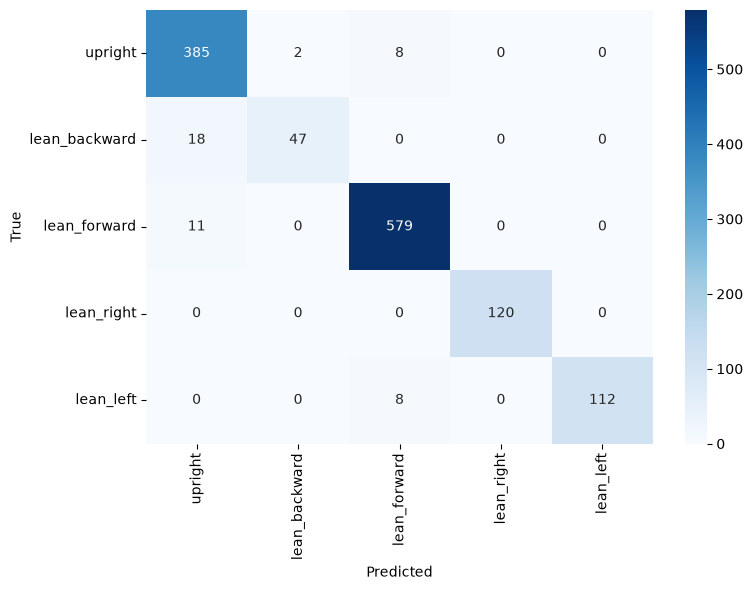

,importance
left_shoulder_x,0.048951
right_shoulder_x,0.045204
left_shoulder_z,0.044105
left_ear_x,0.041774
right_ear_x,0.040006
mouth_right_z,0.039110
mouth_left_x,0.036798
left_ear_z,0.036661
mouth_left_z,0.034902
right_shoulder_z,0.034290


In [5]:
model=RandomForestClassifier(n_estimators=500,class_weight='balanced_subsample',min_samples_leaf=2,max_features='sqrt',n_jobs=-1,random_state=42)
model.fit(X_train,y_train); val_pred=model.predict(X_val); print('Validation macro-F1:',f1_score(y_val,val_pred,average='macro'))
# Refit only after configuration is frozen; test remains untouched until this line.
model.fit(pd.concat([X_train,X_val]),pd.concat([y_train,y_val])); test_pred=model.predict(X_test)
metrics={'accuracy':float(accuracy_score(y_test,test_pred)),'macro_f1':float(f1_score(y_test,test_pred,average='macro')),'weighted_f1':float(f1_score(y_test,test_pred,average='weighted'))}
print(metrics); print(classification_report(y_test,test_pred,digits=4,zero_division=0))
order=list(LABEL_MAP.values()); cm=confusion_matrix(y_test,test_pred,labels=order); plt.figure(figsize=(8,6)); sns.heatmap(cm,annot=True,fmt='d',xticklabels=order,yticklabels=order,cmap='Blues'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()
importance=pd.Series(model.feature_importances_,index=feature_columns).sort_values(ascending=False); display(importance.head(15).to_frame('importance'))

## 6. Save model and webcam feature contract

In [6]:
MODEL_FILE=MODEL_DIR/'multiposture_upper_body_rf.joblib'; CONTRACT_FILE=MODEL_DIR/'multiposture_upper_body_contract.json'
joblib.dump(model,MODEL_FILE)
contract={'created_utc':datetime.now(timezone.utc).isoformat(),'source_doi':DOI,'source_url':URL,'source_md5':digest,'participant_column':PARTICIPANT,'upper_label_column':UPPER_LABEL,'feature_columns':feature_columns,'classes':list(model.classes_),'label_map':LABEL_MAP,'split_unit':'participant','test_metrics':metrics,'limitations':['No raw videos are provided.','Dataset uses 11 MediaPipe-derived joints rather than MotionBERT H36M-17.','Only upright and trunk-lean classes map cleanly to the webcam system.','Do not apply this model to webcam features until Notebook 08 verifies coordinate names, order, scale, and joint mapping.']}
CONTRACT_FILE.write_text(json.dumps(contract,indent=2),encoding='utf-8'); pd.DataFrame({'true':y_test.to_numpy(),'predicted':test_pred,'participant':groups.iloc[test_i].to_numpy()}).to_csv(RESULT_DIR/'test_predictions.csv',index=False); split_table.to_csv(RESULT_DIR/'participant_split_summary.csv',index=False)
print('Saved:',MODEL_FILE.resolve()); print('Saved:',CONTRACT_FILE.resolve())

Saved: C:\Users\manth\Desktop\project_v2\models\multiposture_upper_body_rf.joblib
Saved: C:\Users\manth\Desktop\project_v2\models\multiposture_upper_body_contract.json


## Next step

Inspect the detected schema and results before integration. Notebook 08 will create a verified adapter from the webcam/MotionBERT skeleton to the exact 33-feature contract. If the joint names or coordinate conventions cannot be matched faithfully, the classifier will remain an external benchmark rather than being forced into the webcam.